# ARIMA Model Testing

In [27]:
import itertools
import logging
import os
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from dotenv import load_dotenv
from scipy import stats
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')
COVID_RECOVERY_END = pd.Timestamp('2022-06-30')

sns.set_palette('colorblind')
warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)

mlflow.set_experiment('Brazil Tourism Forecasting ARIMA')

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1781132358379, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781132358379, lifecycle_stage='active', name='Brazil Tourism Forecasting ARIMA', tags={}, trace_location=None, workspace='default'>

## Data Preparation

Several training data selections are evaluated in the grid search:

- **`last_{14,12,10,8,6,4}y_covid_exog`** — last N years with a 0/1 COVID regressor (`is_covid`) to absorb the structural break
- **`last_{14,12,10,8,6,4}y_covid_recovery_exog`** — same windows but with **two** regressors: `is_covid` (Jan 2020–Dec 2021) **and** `is_covid_recovery` (Jan 2022–Jun 2022), the 12-month rebound period immediately after the pandemic
- **`post_covid`** — only post-COVID data (2022 onwards); no exog needed, cleaner signal
- **`post_covid_recovery_exog`** — same post-COVID window with `is_covid_recovery` (Jan 2022–Jun 2022) to explicitly model the rebound year within that short series

Evaluation metrics are computed on **test.parquet** (Jan–Dec 2025) for all models.

In [28]:
train_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))
train_monthly = train_df.set_index('date')[['arrival_count']].resample('ME').sum()
train_monthly['is_covid'] = (
    (train_monthly.index >= COVID_START) & (train_monthly.index <= COVID_END)
).astype(float)
train_monthly['is_covid_recovery'] = (
    (train_monthly.index >= POST_COVID_START)
    & (train_monthly.index <= COVID_RECOVERY_END)
).astype(float)

test_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'test.parquet'))
test_monthly = test_df.set_index('date')[['arrival_count']].resample('ME').sum()
test_monthly['is_covid'] = 0.0
test_monthly['is_covid_recovery'] = 0.0

window_years = [14, 12, 10, 8, 6, 4]
train_windows = {}
for years in window_years:
    start = train_monthly.index[-1] - pd.DateOffset(years=years)
    train_windows[years] = train_monthly[train_monthly.index >= start].copy()

train_post_covid = train_monthly[train_monthly.index >= POST_COVID_START].copy()

print(
    f'Full train  : {train_monthly.index[0].strftime("%b %Y")} → {train_monthly.index[-1].strftime("%b %Y")} ({len(train_monthly)} obs)'
)
for years in window_years:
    tw = train_windows[years]
    print(
        f'Last {years:>2}y    : {tw.index[0].strftime("%b %Y")} → {tw.index[-1].strftime("%b %Y")} ({len(tw)} obs, COVID obs: {int(tw["is_covid"].sum())}, recovery obs: {int(tw["is_covid_recovery"].sum())})'
    )
print(
    f'Post-COVID  : {train_post_covid.index[0].strftime("%b %Y")} → {train_post_covid.index[-1].strftime("%b %Y")} ({len(train_post_covid)} obs)'
)
print(
    f'Test        : {test_monthly.index[0].strftime("%b %Y")} → {test_monthly.index[-1].strftime("%b %Y")} ({len(test_monthly)} obs)'
)

Full train  : jan 1989 → dez 2024 (432 obs)
Last 14y    : dez 2010 → dez 2024 (169 obs, COVID obs: 24, recovery obs: 6)
Last 12y    : dez 2012 → dez 2024 (145 obs, COVID obs: 24, recovery obs: 6)
Last 10y    : dez 2014 → dez 2024 (121 obs, COVID obs: 24, recovery obs: 6)
Last  8y    : dez 2016 → dez 2024 (97 obs, COVID obs: 24, recovery obs: 6)
Last  6y    : dez 2018 → dez 2024 (73 obs, COVID obs: 24, recovery obs: 6)
Last  4y    : dez 2020 → dez 2024 (49 obs, COVID obs: 13, recovery obs: 6)
Post-COVID  : jan 2022 → dez 2024 (36 obs)
Test        : jan 2025 → dez 2025 (12 obs)


## MLflow Setup

In [29]:
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.statsmodels.autolog(log_models=True, log_datasets=False)

print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Tracking URI: http://127.0.0.1:5000


## Model Selection Grid

Grid dimensions:
- **SARIMAX orders**: `p, q ∈ {0,1,2}`, `P, Q ∈ {0,1}`, `d=D=1` fixed from stationarity tests → 36 configs
- **Training data selection**: `last_14y/12y/10y/8y/6y/4y_covid_exog`, `last_14y/12y/10y/8y/6y/4y_covid_recovery_exog`, `post_covid`, or `post_covid_recovery_exog` → 14 options
- **Total runs**: 504 — one MLflow run per (order, data selection)

In [30]:
d, D, s = 1, 1, 12

p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)

sarimax_grid = list(itertools.product(p_range, q_range, P_range, Q_range))

data_configs = {}

for years in window_years:
    tw = train_windows[years]
    # COVID indicator only
    data_configs[f'last_{years}y_covid_exog'] = {
        'series': np.log(tw['arrival_count']),
        'exog_train': tw[['is_covid']],
        'exog_test': test_monthly[['is_covid']],
    }
    # COVID indicator + recovery indicator (Jan–Dec 2022)
    data_configs[f'last_{years}y_covid_recovery_exog'] = {
        'series': np.log(tw['arrival_count']),
        'exog_train': tw[['is_covid', 'is_covid_recovery']],
        'exog_test': test_monthly[['is_covid', 'is_covid_recovery']],
    }

data_configs['post_covid'] = {
    'series': np.log(train_post_covid['arrival_count']),
    'exog_train': None,
    'exog_test': None,
}

# Post-COVID window with recovery flag to model the Jan–Dec 2022 rebound explicitly
data_configs['post_covid_recovery_exog'] = {
    'series': np.log(train_post_covid['arrival_count']),
    'exog_train': train_post_covid[['is_covid_recovery']],
    'exog_test': test_monthly[['is_covid_recovery']],
}

print(f'SARIMAX configs : {len(sarimax_grid)}')
print(f'Data selections : {len(data_configs)}')
print(f'Total runs      : {len(sarimax_grid) * len(data_configs)}')

SARIMAX configs : 36
Data selections : 14
Total runs      : 504


In [31]:
test_actual = test_monthly['arrival_count'].values
n_test = len(test_monthly)
results = []

for data_key, config in data_configs.items():
    if config['exog_train'] is not None:
        exog_cols = list(config['exog_train'].columns)
        exog_label = '+'.join(exog_cols)
    else:
        exog_label = 'none'

    for p, q, P, Q in tqdm(sarimax_grid, desc=f'[{data_key}]'):
        order = (p, d, q)
        seasonal_order = (P, D, Q, s)
        run_name = f'SARIMAX({p},{d},{q})({P},{D},{Q})[{s}] ({data_key})'

        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({
                'p': p,
                'd': d,
                'q': q,
                'P': P,
                'D': D,
                'Q': Q,
                's': s,
                'transform': 'log',
                'data_selection': data_key,
                'exog': exog_label,
                'n_train': len(config['series']),
                'n_test': n_test,
            })

            try:
                model = SARIMAX(
                    config['series'],
                    exog=config['exog_train'],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fit = model.fit(disp=False)

                forecast_log = fit.forecast(steps=n_test, exog=config['exog_test'])
                forecast = np.exp(forecast_log)

                rmse = float(np.sqrt(np.mean((test_actual - forecast) ** 2)))
                mae = float(np.mean(np.abs(test_actual - forecast)))
                mape = float(
                    np.mean(np.abs((test_actual - forecast) / test_actual)) * 100
                )
                r2 = float(r2_score(test_actual, forecast))

                mlflow.log_metrics({
                    'aicc': fit.aicc,
                    'aic': fit.aic,
                    'bic': fit.bic,
                    'rmse': rmse,
                    'mae': mae,
                    'mape': mape,
                    'r2': r2,
                })

                results.append({
                    'data_selection': data_key,
                    'run_name': run_name,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aicc': fit.aicc,
                    'aic': fit.aic,
                    'bic': fit.bic,
                    'rmse': rmse,
                    'mae': mae,
                    'mape': mape,
                    'r2': r2,
                    'converged': True,
                })

            except Exception as exc:
                mlflow.log_param('error', str(exc)[:250])
                results.append({
                    'data_selection': data_key,
                    'run_name': run_name,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': np.inf,
                    'bic': np.inf,
                    'rmse': np.inf,
                    'mae': np.inf,
                    'mape': np.inf,
                    'r2': -np.inf,
                    'converged': False,
                })

results_df = (
    pd.DataFrame(results).query('converged').sort_values('rmse').reset_index(drop=True)
)

print(f'Converged: {len(results_df)} / {len(sarimax_grid) * len(data_configs)}')
results_df.head(10)

[post_covid_recovery_exog]: 100%|██████████| 36/36 [02:34<00:00,  4.30s/it]

Converged: 504 / 504


,data_selection,run_name,order,seasonal_order,aicc,aic,bic,rmse,mae,mape,r2,converged
0,post_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,1)[12] (post_covid_recovery...","(1, 1, 2)","(1, 1, 1, 12)",inf,-21.494666,-20.938575,64174.076552,53222.817557,7.289725,0.959021,True
1,post_covid,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid)","(2, 1, 2)","(1, 1, 1, 12)",inf,-26.858819,-26.302729,74271.699991,57263.813089,7.077313,0.945110,True
2,post_covid_recovery_exog,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid_recovery...","(2, 1, 2)","(1, 1, 1, 12)",inf,-30.289983,-29.654450,79194.821878,60230.253373,7.249916,0.937592,True
3,last_8y_covid_recovery_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_recov...","(2, 1, 1)","(1, 1, 0, 12)",205.033077,203.226626,218.966093,83431.536975,63051.874607,7.489012,0.930736,True
4,last_14y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_exog)","(2, 1, 1)","(1, 1, 0, 12)",312.872250,312.250027,329.984990,84199.534968,62686.530821,7.406782,0.929455,True
5,last_8y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_exog)","(1, 1, 2)","(1, 1, 0, 12)",206.237301,204.924801,218.500880,84609.031197,62550.028928,7.243460,0.928767,True
6,last_8y_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_recov...","(1, 1, 2)","(1, 1, 0, 12)",208.699659,206.921881,222.760640,84612.853154,62593.797259,7.257564,0.928761,True
7,last_10y_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_reco...","(1, 1, 2)","(1, 1, 0, 12)",246.607020,245.319664,263.196802,84777.887842,62739.728597,7.259247,0.928483,True
8,last_10y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)","(1, 1, 2)","(1, 1, 0, 12)",244.280739,243.326194,258.649455,84793.635332,62800.391826,7.261961,0.928456,True
9,last_10y_covid_recovery_exog,"SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_reco...","(1, 1, 1)","(1, 1, 0, 12)",241.783929,240.829383,256.152645,85948.020734,63295.102656,7.397457,0.926495,True


## Results

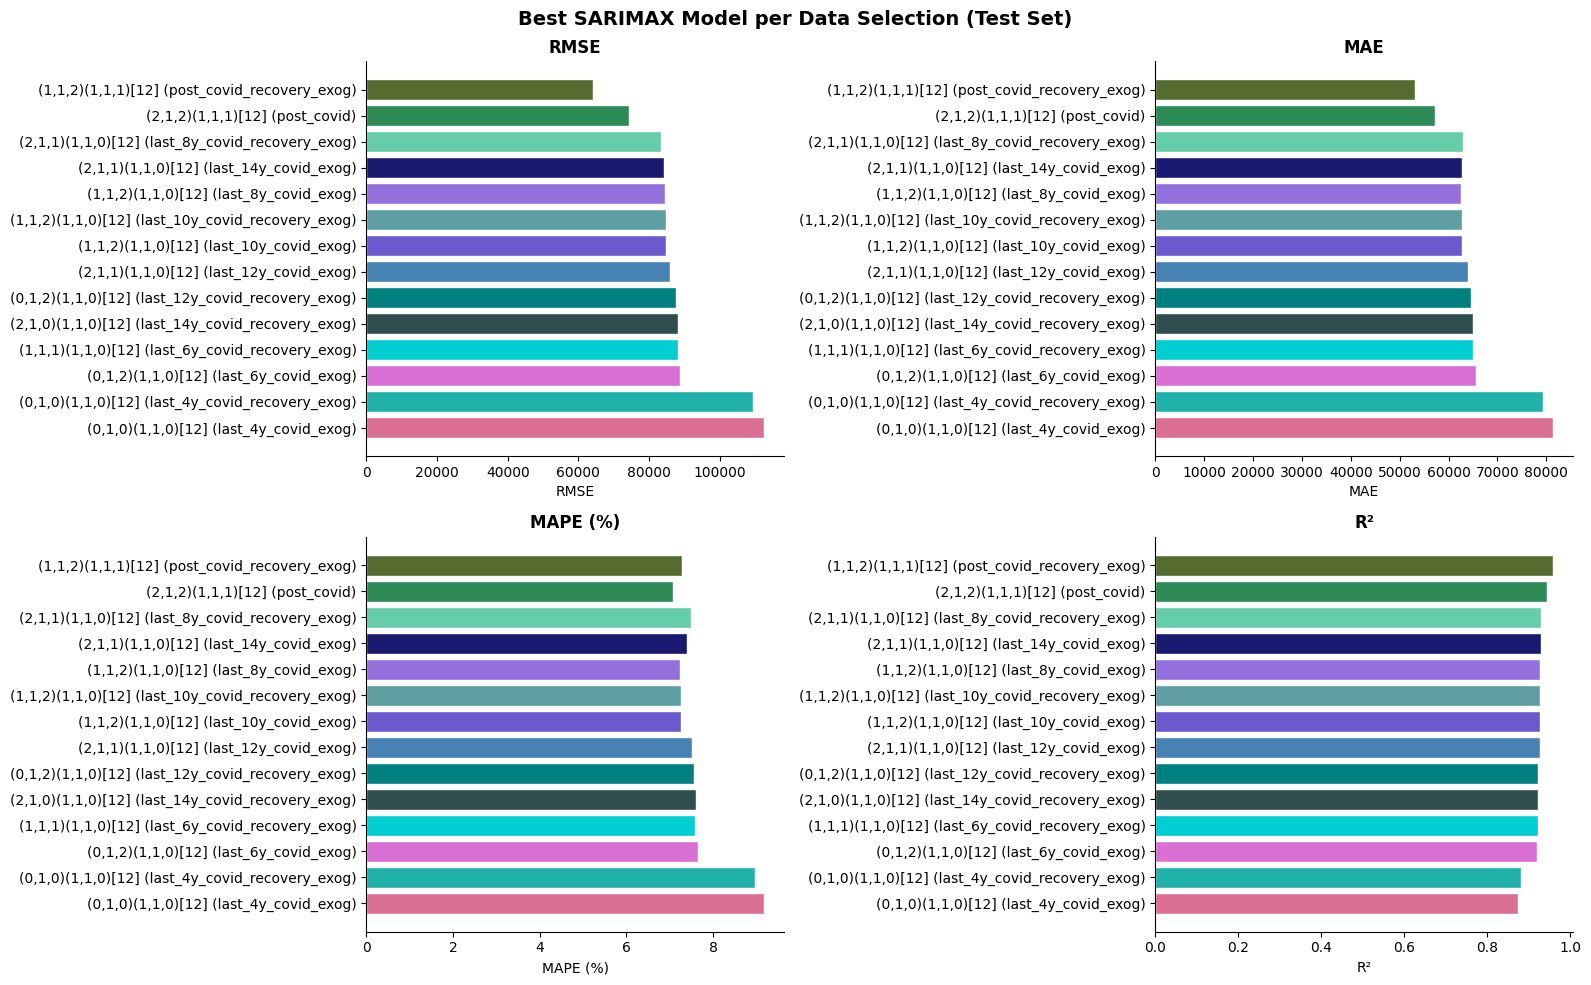

,data_selection,run_name,aic,bic,rmse,mae,mape,r2
0,post_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,1)[12] (post_covid_recovery...",-21.494666,-20.938575,64174.076552,53222.817557,7.289725,0.959021
1,post_covid,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid)",-26.858819,-26.302729,74271.699991,57263.813089,7.077313,0.945110
2,last_8y_covid_recovery_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_recov...",203.226626,218.966093,83431.536975,63051.874607,7.489012,0.930736
3,last_14y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_exog)",312.250027,329.984990,84199.534968,62686.530821,7.406782,0.929455
4,last_8y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_exog)",204.924801,218.500880,84609.031197,62550.028928,7.243460,0.928767
5,last_10y_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_reco...",245.319664,263.196802,84777.887842,62739.728597,7.259247,0.928483
6,last_10y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)",243.326194,258.649455,84793.635332,62800.391826,7.261961,0.928456
7,last_12y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_12y_covid_exog)",278.114605,294.738713,85972.730824,63890.166133,7.517813,0.926453
8,last_12y_covid_recovery_exog,"SARIMAX(0,1,2)(1,1,0)[12] (last_12y_covid_reco...",281.557749,298.282699,87654.325157,64656.132421,7.555035,0.923547
9,last_14y_covid_recovery_exog,"SARIMAX(2,1,0)(1,1,0)[12] (last_14y_covid_reco...",314.224542,331.959504,88056.833193,65102.725237,7.612575,0.922844


In [32]:
palette = {
    'last_14y_covid_exog': 'midnightblue',
    'last_12y_covid_exog': 'steelblue',
    'last_10y_covid_exog': 'slateblue',
    'last_8y_covid_exog': 'mediumpurple',
    'last_6y_covid_exog': 'orchid',
    'last_4y_covid_exog': 'palevioletred',
    'last_14y_covid_recovery_exog': 'darkslategray',
    'last_12y_covid_recovery_exog': 'teal',
    'last_10y_covid_recovery_exog': 'cadetblue',
    'last_8y_covid_recovery_exog': 'mediumaquamarine',
    'last_6y_covid_recovery_exog': 'darkturquoise',
    'last_4y_covid_recovery_exog': 'lightseagreen',
    'post_covid': 'seagreen',
    'post_covid_recovery_exog': 'darkolivegreen',
}

best_per_selection = (
    results_df
    .sort_values('rmse')
    .groupby('data_selection', sort=False)
    .first()
    .reset_index()
    .sort_values('rmse')
    .reset_index(drop=True)
)
best_per_selection['label'] = best_per_selection['run_name'].str.replace(
    'SARIMAX', '', regex=False
)
bar_colors = [palette[ds] for ds in best_per_selection['data_selection'][::-1]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Best SARIMAX Model per Data Selection (Test Set)',
    fontsize=14,
    fontweight='bold',
)

for ax, (col, title) in zip(
    axes.flat, [('rmse', 'RMSE'), ('mae', 'MAE'), ('mape', 'MAPE (%)'), ('r2', 'R²')]
):
    ax.barh(
        best_per_selection['label'][::-1],
        best_per_selection[col][::-1],
        color=bar_colors,
        edgecolor='white',
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

display(
    best_per_selection[
        ['data_selection', 'run_name', 'aic', 'bic', 'rmse', 'mae', 'mape', 'r2']
    ]
)

## Best Model Diagnostics

In [33]:
top10 = results_df.head(10).copy()

display(
    top10[
        [
            'data_selection',
            'run_name',
            'aicc',
            'aic',
            'bic',
            'rmse',
            'mae',
            'mape',
            'r2',
        ]
    ]
)

,data_selection,run_name,aicc,aic,bic,rmse,mae,mape,r2
0,post_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,1)[12] (post_covid_recovery...",inf,-21.494666,-20.938575,64174.076552,53222.817557,7.289725,0.959021
1,post_covid,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid)",inf,-26.858819,-26.302729,74271.699991,57263.813089,7.077313,0.945110
2,post_covid_recovery_exog,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid_recovery...",inf,-30.289983,-29.654450,79194.821878,60230.253373,7.249916,0.937592
3,last_8y_covid_recovery_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_recov...",205.033077,203.226626,218.966093,83431.536975,63051.874607,7.489012,0.930736
4,last_14y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_exog)",312.872250,312.250027,329.984990,84199.534968,62686.530821,7.406782,0.929455
5,last_8y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_exog)",206.237301,204.924801,218.500880,84609.031197,62550.028928,7.243460,0.928767
6,last_8y_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_recov...",208.699659,206.921881,222.760640,84612.853154,62593.797259,7.257564,0.928761
7,last_10y_covid_recovery_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_reco...",246.607020,245.319664,263.196802,84777.887842,62739.728597,7.259247,0.928483
8,last_10y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)",244.280739,243.326194,258.649455,84793.635332,62800.391826,7.261961,0.928456
9,last_10y_covid_recovery_exog,"SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_reco...",241.783929,240.829383,256.152645,85948.020734,63295.102656,7.397457,0.926495


In [34]:
def fit_model(row, configs):
    cfg = configs[row['data_selection']]
    return SARIMAX(
        cfg['series'],
        exog=cfg['exog_train'],
        order=row['order'],
        seasonal_order=row['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


top10_fits = [fit_model(row, data_configs) for _, row in top10.iterrows()]

for i, (_, row) in enumerate(top10.iterrows()):
    print(f'#{i + 1:>2}  [{row["data_selection"]}]  {row["run_name"]}')

# 1  [post_covid_recovery_exog]  SARIMAX(1,1,2)(1,1,1)[12] (post_covid_recovery_exog)
# 2  [post_covid]  SARIMAX(2,1,2)(1,1,1)[12] (post_covid)
# 3  [post_covid_recovery_exog]  SARIMAX(2,1,2)(1,1,1)[12] (post_covid_recovery_exog)
# 4  [last_8y_covid_recovery_exog]  SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_recovery_exog)
# 5  [last_14y_covid_exog]  SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_exog)
# 6  [last_8y_covid_exog]  SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_exog)
# 7  [last_8y_covid_recovery_exog]  SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_recovery_exog)
# 8  [last_10y_covid_recovery_exog]  SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_recovery_exog)
# 9  [last_10y_covid_exog]  SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)
#10  [last_10y_covid_recovery_exog]  SARIMAX(1,1,1)(1,1,0)[12] (last_10y_covid_recovery_exog)


### Residual Diagnostics

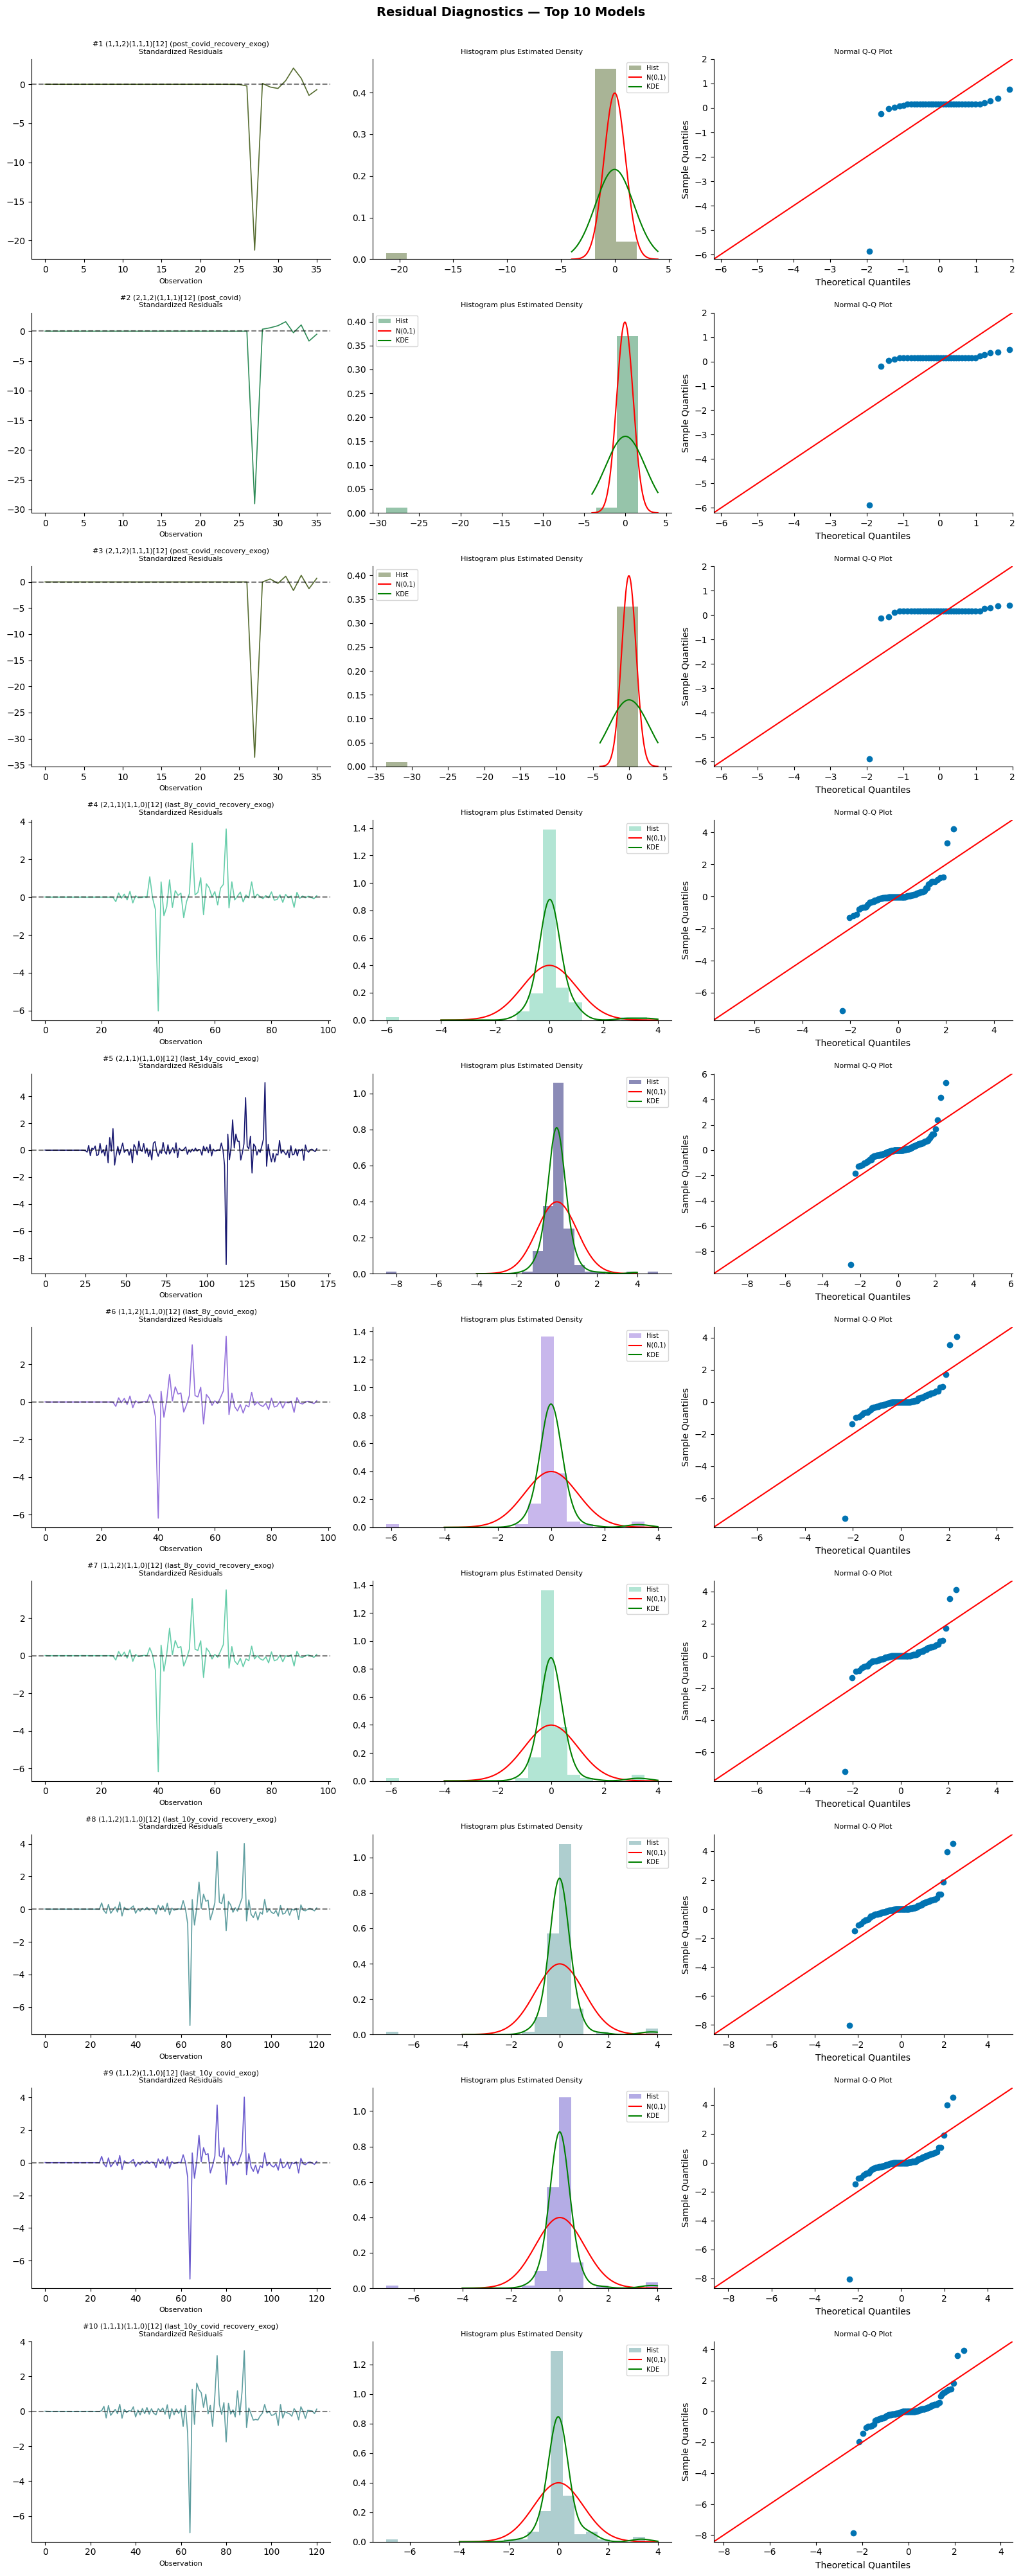

In [35]:
fig, axes = plt.subplots(10, 3, figsize=(16, 40))
fig.suptitle(
    'Residual Diagnostics — Top 10 Models', fontsize=14, fontweight='bold', y=1.001
)

x_qq = np.linspace(-4, 4, 200)

for i, ((_, row), fit) in enumerate(zip(top10.iterrows(), top10_fits)):
    std_resid = fit.filter_results.standardized_forecasts_error[0]
    std_resid = std_resid[~np.isnan(std_resid)]

    row_label = f'#{i + 1} {row["run_name"].replace("SARIMAX", "")}'

    # Standardized residuals over time
    axes[i, 0].plot(std_resid, linewidth=1.2, color=palette[row['data_selection']])
    axes[i, 0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[i, 0].set_title(f'{row_label}\nStandardized Residuals', fontsize=8)
    axes[i, 0].set_xlabel('Observation', fontsize=8)
    sns.despine(ax=axes[i, 0])

    # Histogram + KDE + N(0,1)
    axes[i, 1].hist(
        std_resid,
        bins='auto',
        density=True,
        alpha=0.5,
        color=palette[row['data_selection']],
        label='Hist',
    )
    axes[i, 1].plot(x_qq, stats.norm.pdf(x_qq, 0, 1), 'r-', label='N(0,1)')
    kde = stats.gaussian_kde(std_resid)
    axes[i, 1].plot(x_qq, kde(x_qq), 'g-', label='KDE')
    axes[i, 1].set_title('Histogram plus Estimated Density', fontsize=8)
    axes[i, 1].legend(fontsize=7)
    sns.despine(ax=axes[i, 1])

    # Normal Q-Q plot
    sm.qqplot(std_resid, line='45', fit=True, ax=axes[i, 2])
    axes[i, 2].set_title('Normal Q-Q Plot', fontsize=8)
    sns.despine(ax=axes[i, 2])

plt.tight_layout()
plt.show()

### Final Result

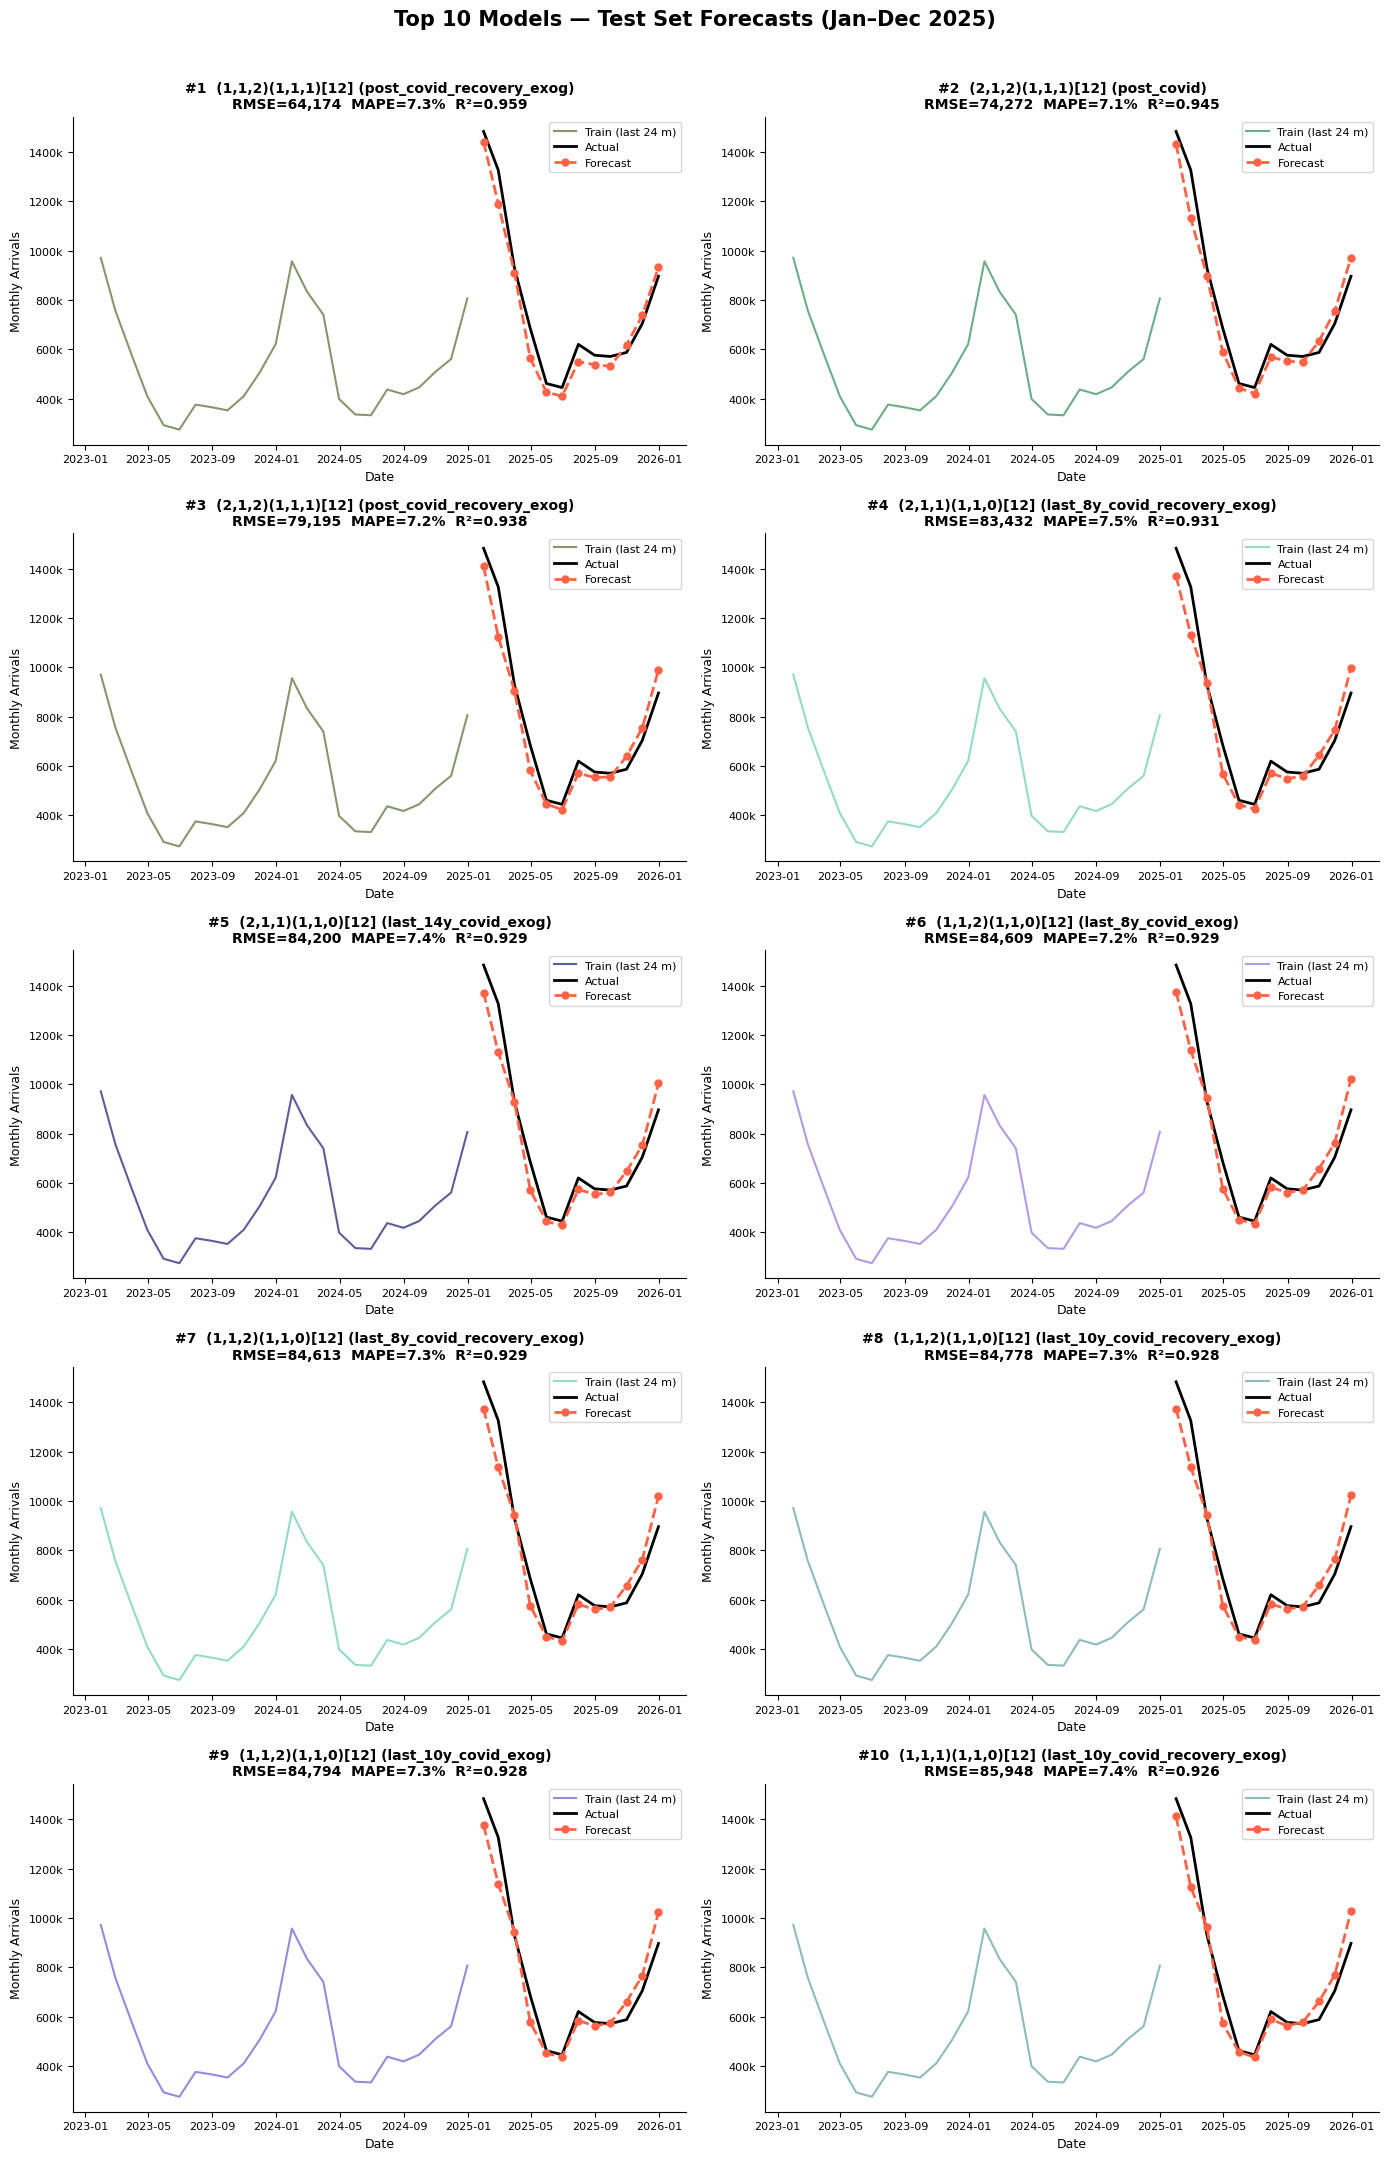

In [36]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
fig.suptitle(
    'Top 10 Models — Test Set Forecasts (Jan–Dec 2025)', fontsize=15, fontweight='bold'
)

for i, (ax, (_, row), fit) in enumerate(zip(axes.flat, top10.iterrows(), top10_fits)):
    cfg = data_configs[row['data_selection']]
    forecast_log = fit.forecast(steps=n_test, exog=cfg['exog_test'])
    forecast = np.exp(forecast_log)
    train_plot = np.exp(cfg['series']).iloc[-24:]

    ax.plot(
        train_plot.index,
        train_plot.values,
        label='Train (last 24 m)',
        linewidth=1.5,
        color=palette[row['data_selection']],
        alpha=0.7,
    )
    ax.plot(
        test_monthly.index,
        test_monthly['arrival_count'],
        label='Actual',
        linewidth=2,
        color='black',
    )
    ax.plot(
        test_monthly.index,
        forecast,
        label='Forecast',
        linewidth=2,
        linestyle='--',
        color='tomato',
        marker='o',
        markersize=5,
    )

    ax.set_title(
        f'#{i + 1}  {row["run_name"].replace("SARIMAX", "")}\n'
        f'RMSE={row["rmse"]:,.0f}  MAPE={row["mape"]:.1f}%  R²={row["r2"]:.3f}',
        fontsize=10,
        fontweight='bold',
    )
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Monthly Arrivals', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()